In [1]:
import numpy as np
import h5py
import os
import tqdm
import scipy

def remove_extreme_data():

    base_dir = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset"
    save_path = os.path.join(base_dir, "filtered_records.h5")

    fs = 125								# sampling frequency
    t = 8.192									# length of ppg episodes
    dt = 2.048									# step size of taking the next episode

    samples_in_episode = round(fs * t)		# number of samples in an episode
    d_samples = round(fs * dt)

    filt_con = 8 * 60 * fs
    extreme_abp = 200
    
    ppg = []
    abp = []

    for k in range(1, 13):

        print(f"Processing file part {k} out of 12.")

        file_path = os.path.join(base_dir, f"part_{k}.mat")
        file = scipy.io.loadmat(file_path)['p'][0] # 选['p'][0]->p对应字典结构的数据value，[0]对应全部数据(1000条recoding)
        
        for i in range(len(file)):

            if len(file[i][0]) <= filt_con or max(file[i][1]) > extreme_abp:
                continue

            ppg.append(file[i][0]) # list, 存的是一个recording
            abp.append(file[i][1])
        
    with h5py.File(save_path, "w") as f:
        f.create_dataset(
            "ppg",
            data=np.array(ppg, dtype=object),
            dtype=h5py.vlen_dtype(np.float32)
        )
        f.create_dataset(
            "abp",
            data=np.array(abp, dtype=object),
            dtype=h5py.vlen_dtype(np.float32)
        )
    
# with h5py.File("filtered_records.h5", "r") as f:
#    ppg = f["ppg"][i]
#    abp = f["abp"][i]

In [36]:
remove_extreme_data()

Processing file part 1 out of 12.
Processing file part 2 out of 12.
Processing file part 3 out of 12.
Processing file part 4 out of 12.
Processing file part 5 out of 12.
Processing file part 6 out of 12.
Processing file part 7 out of 12.
Processing file part 8 out of 12.
Processing file part 9 out of 12.
Processing file part 10 out of 12.
Processing file part 11 out of 12.
Processing file part 12 out of 12.


In [3]:
float("inf")

inf

In [1]:
import os
base_dir = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset"

save_path = os.path.join(base_dir, "filtered_records.h5")
print(save_path)

E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\filtered_records.h5


In [2]:
indices_dir_base = r"E:\Kaggle_projects\Blood_Pressure_analysis"
fold_dir = os.path.join(indices_dir_base, f"cv_fold_0.npz")
print(fold_dir)

E:\Kaggle_projects\Blood_Pressure_analysis\cv_fold_0.npz


In [37]:
from scipy.signal import detrend

def detrend_ppg(h5_in, h5_out):
    """
    Docstring for detrend_ppg
    
    :param ppg: Description
    """
    with h5py.File(h5_in, "r") as fin, h5py.File(h5_out, "w") as fout:
        ppg_in = fin["ppg"]
        abp_in = fin["abp"]

        ppg_out = fout.create_dataset(
            "ppg",
            shape = (len(ppg_in),),
                     dtype=h5py.vlen_dtype(np.float32)
                     )
        abp_out = fout.create_dataset(
            "abp",
            shape=(len(abp_in),),
            dtype=h5py.vlen_dtype(np.float32)
        )

        for i in range(len(ppg_in)):
            ppg_out[i] = detrend(ppg_in[i]).astype(np.float32)
            abp_out[i] = abp_in[i]

In [3]:
import h5py
import numpy as np

with h5py.File(r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\filtered_records.h5", "r") as f:
    ppg_ds = f["ppg"]
    ppg_read = np.array(ppg_ds, dtype=object)

In [6]:
with h5py.File(r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\detrend_records.h5", "r") as f:
    ppg_ds = f["ppg"]
    ppg_detrend = np.array(ppg_ds, dtype=object)

In [1]:
list = []
window = [1, 2, 3]
for i in range(10):
    list.append(window)
list



[[1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3],
 [1, 2, 3]]

In [ ]:
import numpy as np

lists = np.stack(list)

array([[1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3],
       [1, 2, 3]])

In [6]:
from data_helper import zscore_normalization
detrend_h5data = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\detrend_records.h5"
scaled_h5data = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\scaled_records.h5"

zscore_normalization(detrend_h5data, scaled_h5data)

In [ ]:
num = np.ndarray(5)
list = []
list.append(num)
list

[5]

In [1]:
from data_helper import window_seg

scaled_h5data = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\scaled_records.h5"
segmented_h5data = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\segmented_records.h5"

window_seg(scaled_h5data, segmented_h5data)

In [5]:
import h5py
import numpy as np

with h5py.File(r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\segmented_records.h5", "r") as f:
    ppg_ds = f["ppg"]
    sbp_ds = f["sbp"]
    dbp_ds = f["dbp"]
    record_id_ds = f["record_id"]
    abp_ds = f["abp"]
    
    ppg_data = ppg_ds[:]
    sbp_data = sbp_ds[:]
    dbp_data = dbp_ds[:]
    record_id_data = record_id_ds[:]
    abp_data = abp_ds[:]

In [3]:
ppg_data.shape

(517305, 1024)

In [4]:
sbp_data.shape

(517305,)

In [5]:
sbp_data

array([122.782585, 123.81981 , 124.82721 , ..., 104.594765, 104.57523 ,
       104.174706], dtype=float32)

In [6]:
record_id_data.shape

(517305,)

In [9]:
abp_data.shape

(517305, 1024)

In [1]:
import numpy as np
idx = np.load("cv_fold_0.npz")
idx

NpzFile 'cv_fold_0.npz' with keys: train_idx, val_idx

In [2]:
idx["train_idx"]

array([     0,      1,      2, ..., 517302, 517303, 517304], dtype=int64)

In [3]:
idx["train_idx"].shape

(413840,)

In [4]:
idx["train_idx"][1]

1

In [6]:
ppg_data[idx["train_idx"][1]]

array([-0.52647555, -0.55277056, -0.5821593 , ...,  0.14361279,
        0.03224458, -0.06674951], dtype=float32)

In [7]:
ppg_data[idx["train_idx"][1]].shape

(1024,)

In [8]:
abp_data[idx["train_idx"][1]]

array([117.17701 , 118.88655 , 119.570366, ...,  69.9936  ,  72.19159 ,
        77.857506], dtype=float32)

In [9]:
abp_data[idx["train_idx"][1]].shape

(1024,)

In [10]:
dbp_data[idx["train_idx"][1]]

68.2688

In [14]:
sbp_data[idx["train_idx"][1]]

123.81981

In [12]:
import torch

x = torch.tensor(ppg_data[idx["train_idx"][1]], dtype=torch.float32)
x

tensor([-0.5265, -0.5528, -0.5822,  ...,  0.1436,  0.0322, -0.0667])

In [13]:
x.shape

torch.Size([1024])

In [15]:
y = torch.tensor([sbp_data[idx["train_idx"][1]], dbp_data[idx["train_idx"][1]]], dtype=torch.float32)
y

tensor([123.8198,  68.2688])

In [16]:
y.shape

torch.Size([2])

In [14]:
len(idx["train_idx"])

413840

In [16]:
idx["val_idx"]

array([  6134,   6135,   6136, ..., 517055, 517056, 517057], dtype=int64)

In [ ]:
with h5py.File("segmented_records.h5", "r") as f:
    X_train = f["ppg"][idx["train_idx"]]

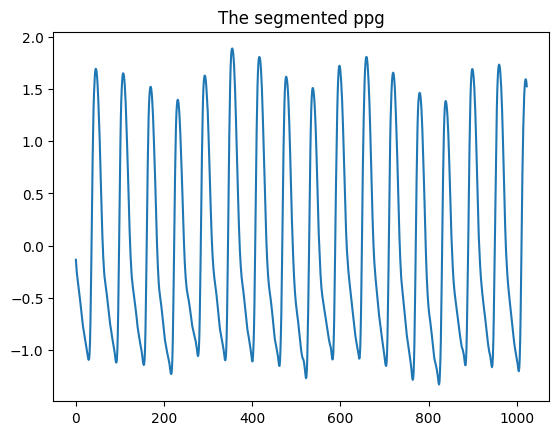

In [3]:
import matplotlib.pyplot as plt

plt.plot(ppg_data[0])
plt.title("The segmented ppg")
plt.show()

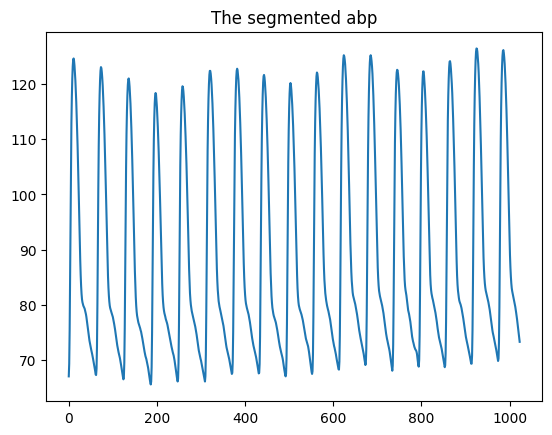

In [4]:
plt.plot(abp_data[0])
plt.title("The segmented abp")
plt.show()

In [1]:
from data_helper import k_fold_save

segmented_h5data = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\segmented_records.h5"
k_fold_save(k=5, data_path=segmented_h5data)

In [ ]:
import numpy as np

idx = np.load("cv_fold_0.npz")
idx

NpzFile 'cv_fold_1.npz' with keys: train_idx, val_idx

In [7]:
ppg_data.shape

(517305, 1024)

In [10]:
sbp_data.shape

(517305,)

In [11]:
record_id_data.shape

(517305,)

In [12]:
record_id_data

array([   0,    0,    0, ..., 1966, 1966, 1966])

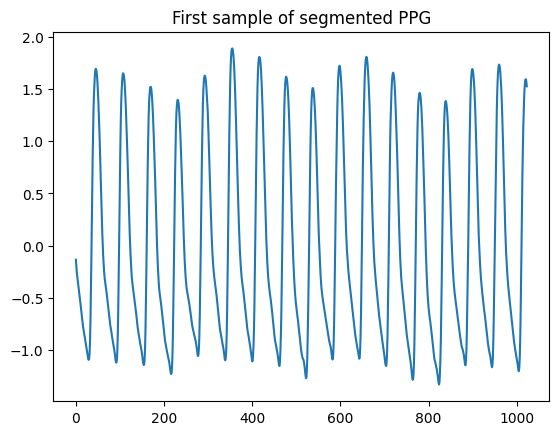

In [8]:
import matplotlib.pyplot as plt

plt.plot(ppg_data[0])
plt.title("First sample of segmented PPG")
plt.show()

In [4]:
type(ppg_ds)

h5py._hl.dataset.Dataset

In [4]:
lists.shape

(10, 3)

In [4]:
len(ppg_read)

1967

In [11]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ids = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
for fold, (train_ids_idx, val_ids_idx) in enumerate(kf.split(ids)):
    print(fold)
    print(train_ids_idx)
    print(val_ids_idx)

0
[ 1  2  3  4  5  6  7  8 11]
[ 0  9 10]
1
[ 0  1  3  4  6  7  9 10 11]
[2 5 8]
2
[ 0  2  3  4  5  6  7  8  9 10]
[ 1 11]
3
[ 0  1  2  3  5  6  8  9 10 11]
[4 7]
4
[ 0  1  2  4  5  7  8  9 10 11]
[3 6]


In [41]:
ppg_read

array([array([1.7595308, 1.7184751, 1.6842619, ..., 1.6441838, 1.6001955,
              1.5659825], dtype=float32)                                 ,
       array([2.4095798, 2.3294232, 2.2385142, ..., 1.2404692, 1.230694 ,
              1.2199414], dtype=float32)                                 ,
       array([2.4428153, 2.3450634, 2.2424242, ..., 1.5337243, 1.5024438,
              1.4780059], dtype=float32)                                 ,
       ...,
       array([0.3890518 , 0.3841642 , 0.38025415, ..., 0.71358746, 0.7302053 ,
              0.73900294], dtype=float32)                                     ,
       array([0.14760508, 0.10459433, 0.06060606, ..., 1.1661779 , 1.1466275 ,
              1.1319648 ], dtype=float32)                                     ,
       array([1.1407624, 1.1348974, 1.1290323, ..., 2.3597262, 2.3020527,
              2.2394917], dtype=float32)                                 ],
      dtype=object)

In [42]:
lengths = [len(x) for x in ppg_read]
print(np.mean(lengths), np.min(lengths), np.max(lengths))

68188.61209964413 61000 74000


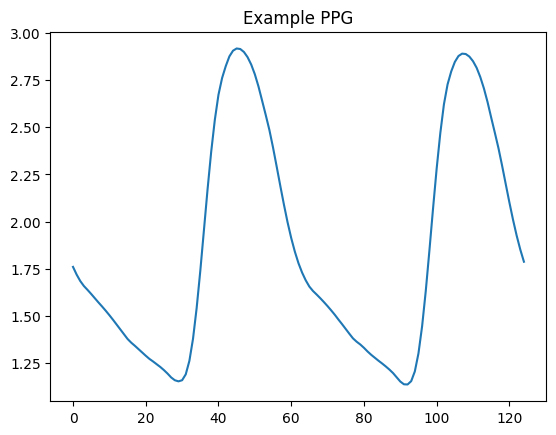

In [5]:
import matplotlib.pyplot as plt

plt.plot(ppg_read[0][:125])
plt.title("Example PPG")
plt.show()

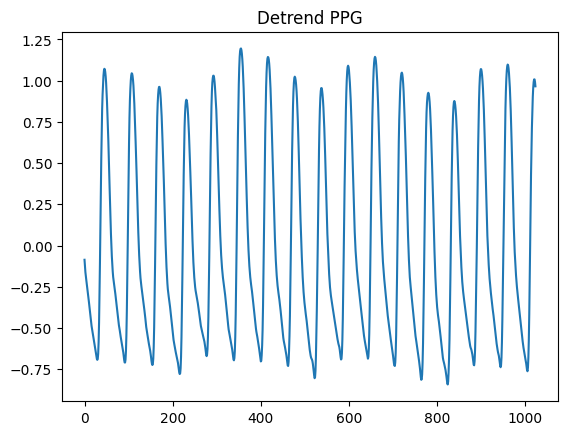

In [9]:
plt.plot(ppg_detrend[0][:1024])
plt.title("Detrend PPG")
plt.show()

In [4]:
import h5py
import numpy as np

with h5py.File(r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\scaled_records.h5", "r") as f:
    ppg_ds = f["ppg"]
    
    ppg_scaled = ppg_ds[:]

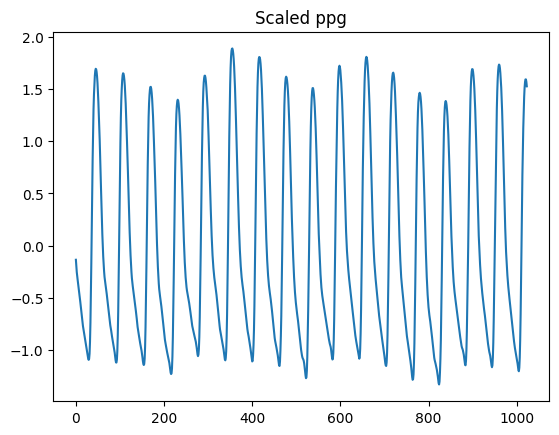

In [7]:
import matplotlib.pyplot as plt


plt.plot(ppg_scaled[0][:1024])
plt.title("Scaled ppg")
plt.show()

In [10]:
len(ppg_detrend)

1967

In [ ]:
import os
import scipy.io

base_dir = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset"

file_path = os.path.join(base_dir, f"part_{1}.mat")
file = scipy.io.loadmat(file_path)['p'][0]
ppg = []
abp = []

for i in range(len(file)):

    if len(file[i][0]) <= 8 * 60 * 125 or max(file[i][1]) > 200:
        continue

    ppg.append(file[i][0]) # list, 存的是一个recording
    abp.append(file[i][1])

# part_1滤掉后还剩218个recording

In [26]:
len(ppg)

218

In [31]:
print(len(ppg[97]))
print(len(ppg[5]))
print(len(ppg[114]))

72000
67000
68000


In [7]:
import h5py
import os
import tqdm
import scipy.io

In [6]:
base_dir = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset"
file_name = "part_1.mat"

file_path = os.path.join(base_dir, file_name)
print(file_path)

E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset\part_1.mat


In [23]:
base_dir = r"E:\Kaggle_projects\Blood_Pressure_analysis\Blood_pressure_dataset"
file_path = os.path.join(base_dir, "part_1.mat")

data = scipy.io.loadmat(file_path)['p'][0]

In [35]:
len(data[1][0])

61000

In [40]:
empty = []
empty.append(data[1][0])
print(type(empty))
empty


<class 'list'>


[array([2.40957967, 2.32942326, 2.23851417, ..., 1.24046921, 1.23069404,
        1.21994135])]